--- 1. DATA EXPLORATION & PREPROCESSING ---
Dataset loaded successfully!

--- Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB
None

--- Basic Statistics ---
               Year    hg/ha_yield  average_rain_fall_mm_per_year  \
count  28242.000000   28242.000000                    28242.00000   
mean    2001.544296  

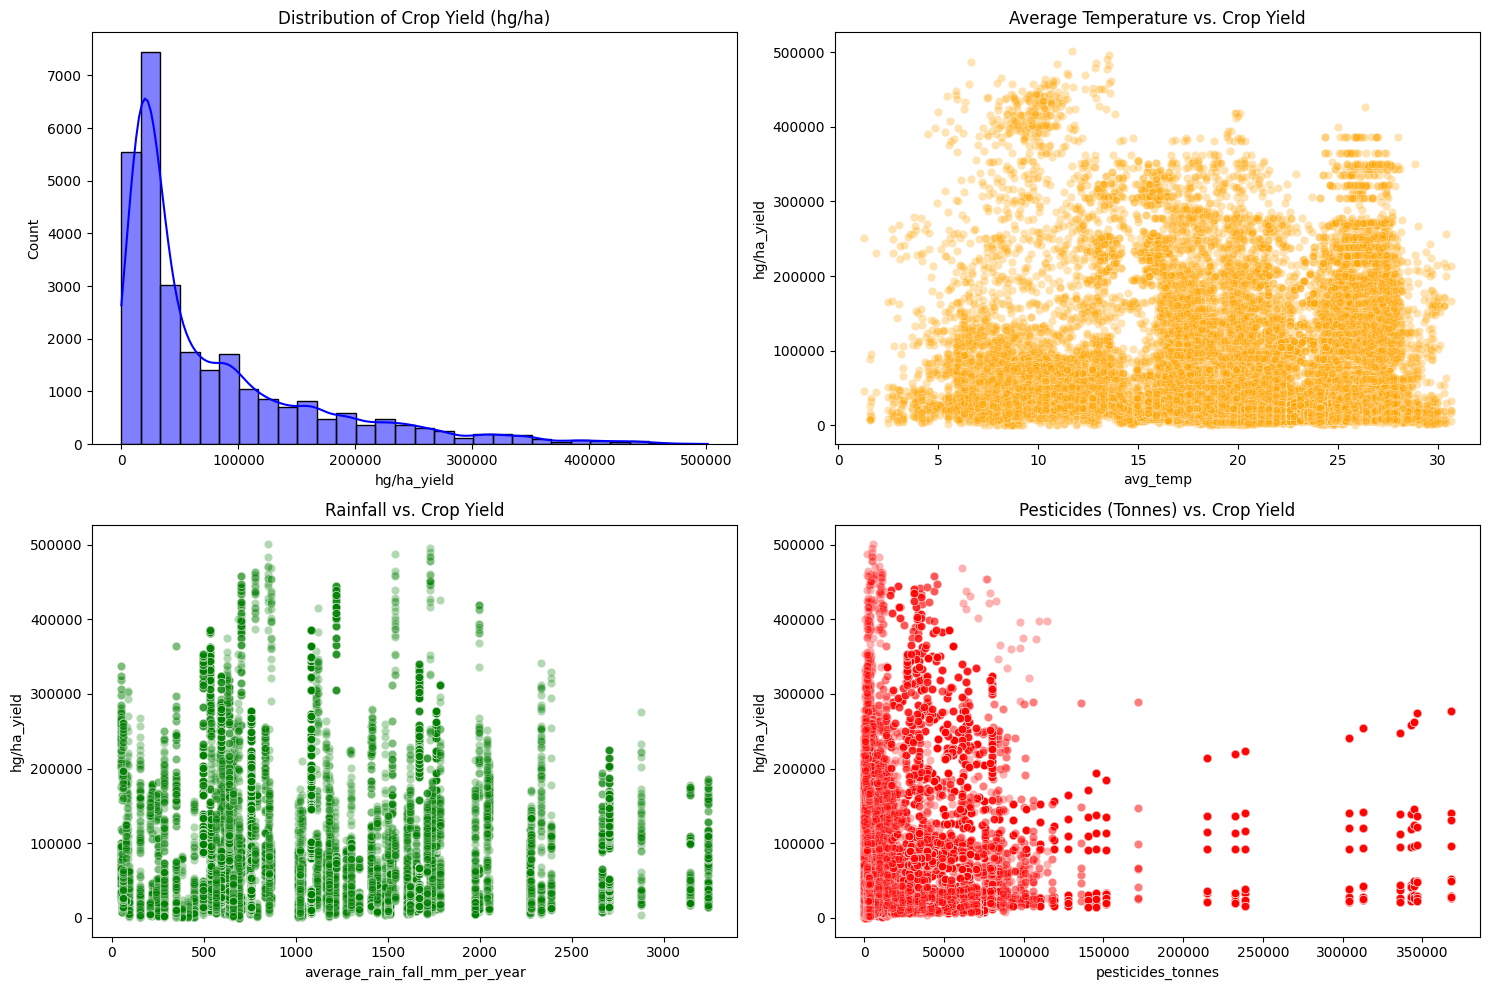


--- 2. FEATURE ENGINEERING ---
New feature 'rain_temp_ratio' created successfully.


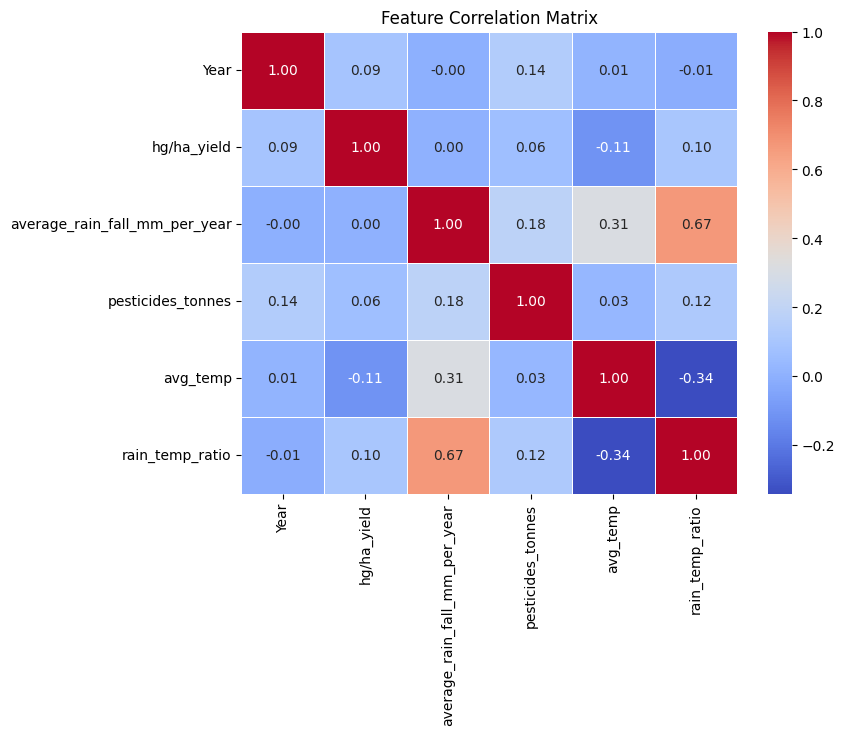


--- 3. MODEL TRAINING & EVALUATION ---
[Linear Regression] MAE: 29582.46 | RMSE: 42144.02 | R2: 0.7551
[Decision Tree] MAE: 3855.26 | RMSE: 13124.59 | R2: 0.9763
[Random Forest] MAE: 3668.18 | RMSE: 9787.36 | R2: 0.9868

--- BONUS: RIDGE & LASSO REGRESSION ---
[Ridge Regression] MAE: 29580.46 | RMSE: 42143.51 | R2: 0.7551
[LASSO Regression] MAE: 29582.22 | RMSE: 42144.00 | R2: 0.7551

--- 4. HYPERPARAMETER TUNING ---
Running Grid Search on Decision Tree...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
[Optimized Decision Tree] MAE: 4376.23 | RMSE: 12576.21 | R2: 0.9782

--- 5. SAVING ASSETS FOR DEPLOYMENT ---
✅ Model, Scaler, and Feature list have been saved successfully!
Files created: 'crop_yield_prediction_model.pkl', 'crop_yield_scaler.pkl', 'model_features.pkl'


In [1]:
# ==============================================================================
# CROP YIELD PREDICTION - FULL PIPELINE (KAGGLE SINGLE CELL)
# ==============================================================================

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. DATA EXPLORATION & PREPROCESSING
# ------------------------------------------------------------------------------
print("--- 1. DATA EXPLORATION & PREPROCESSING ---")

# Load the consolidated dataset (yield_df.csv contains the merged features)
data_path = '/kaggle/input/datasets/patelris/crop-yield-prediction-dataset/yield_df.csv'
try:
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: Could not find {data_path}. Please ensure the path is correct in your Kaggle environment.")
    # Fallback for testing purposes if path is slightly different
    df = pd.read_csv('/kaggle/input/crop-yield-prediction-dataset/yield_df.csv')

# Drop the unnamed index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(['Unnamed: 0'], axis=1)

# Display basic statistics
print("\n--- Basic Information ---")
print(df.info())
print("\n--- Basic Statistics ---")
print(df.describe())

# Handle missing values (Drop them or impute)
missing_values = df.isnull().sum().sum()
print(f"\nTotal missing values before cleaning: {missing_values}")
df = df.dropna()

# Ensure numeric columns are properly typed (Rainfall sometimes has bad formats in raw data)
df['average_rain_fall_mm_per_year'] = pd.to_numeric(df['average_rain_fall_mm_per_year'], errors='coerce')
df = df.dropna() # Drop any rows that became NaN during conversion

# Exploratory Data Analysis (EDA)
plt.figure(figsize=(15, 10))

# Visualizing the distribution of the target variable (Crop Yield)
plt.subplot(2, 2, 1)
sns.histplot(df['hg/ha_yield'], bins=30, kde=True, color='blue')
plt.title('Distribution of Crop Yield (hg/ha)')

# Visualizing Average Temperature vs Yield
plt.subplot(2, 2, 2)
sns.scatterplot(x='avg_temp', y='hg/ha_yield', data=df, alpha=0.3, color='orange')
plt.title('Average Temperature vs. Crop Yield')

# Visualizing Rainfall vs Yield
plt.subplot(2, 2, 3)
sns.scatterplot(x='average_rain_fall_mm_per_year', y='hg/ha_yield', data=df, alpha=0.3, color='green')
plt.title('Rainfall vs. Crop Yield')

# Visualizing Pesticides vs Yield
plt.subplot(2, 2, 4)
sns.scatterplot(x='pesticides_tonnes', y='hg/ha_yield', data=df, alpha=0.3, color='red')
plt.title('Pesticides (Tonnes) vs. Crop Yield')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 2. FEATURE ENGINEERING
# ------------------------------------------------------------------------------
print("\n--- 2. FEATURE ENGINEERING ---")

# Create a new meaningful feature: Climate interaction (Rainfall / Temperature)
# We add a small epsilon (0.1) to avoid division by zero in case of 0 temperatures
df['rain_temp_ratio'] = df['average_rain_fall_mm_per_year'] / (df['avg_temp'] + 0.1)
print("New feature 'rain_temp_ratio' created successfully.")

# Correlation matrix to identify relevant numerical features
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Convert categorical variables into numerical representations (One-Hot Encoding)
# We encode 'Area' (Country) and 'Item' (Crop Type)
categorical_cols = ['Area', 'Item']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define Features (X) and Target (y)
X = df_encoded.drop(['hg/ha_yield'], axis=1)
y = df_encoded['hg/ha_yield']

# Save the feature names for deployment later (Streamlit/Flask will need exactly these columns)
feature_columns = X.columns.tolist()

# ------------------------------------------------------------------------------
# 3. MODEL TRAINING & EVALUATION
# ------------------------------------------------------------------------------
print("\n--- 3. MODEL TRAINING & EVALUATION ---")

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize/Scale numerical features
# It is important to fit the scaler ONLY on the training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize standard models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42) # 50 to keep training time reasonable
}

# Function to evaluate models
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

model_performance = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae, rmse, r2 = evaluate_model(y_test, y_pred)
    model_performance[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"[{name}] MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

# ------------------------------------------------------------------------------
# BONUS CHALLENGE: RIDGE & LASSO COMPARISON
# ------------------------------------------------------------------------------
print("\n--- BONUS: RIDGE & LASSO REGRESSION ---")

bonus_models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "LASSO Regression": Lasso(alpha=0.1)
}

for name, model in bonus_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae, rmse, r2 = evaluate_model(y_test, y_pred)
    model_performance[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"[{name}] MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

# ------------------------------------------------------------------------------
# 4. HYPERPARAMETER TUNING
# ------------------------------------------------------------------------------
print("\n--- 4. HYPERPARAMETER TUNING ---")
# Using Decision Tree for quick tuning demonstration. 
# (Random Forest tuning can take a long time in a single notebook cell).

dt_params = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

print("Running Grid Search on Decision Tree...")
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate the optimized model
y_pred_best = best_model.predict(X_test_scaled)
best_mae, best_rmse, best_r2 = evaluate_model(y_test, y_pred_best)
print(f"[Optimized Decision Tree] MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | R2: {best_r2:.4f}")

# ------------------------------------------------------------------------------
# 5. SAVING THE MODEL & SCALER FOR WEB DEPLOYMENT
# ------------------------------------------------------------------------------
print("\n--- 5. SAVING ASSETS FOR DEPLOYMENT ---")

# We save the best model, the scaler, and the exact feature columns used.
# These three files are critical to load inside your Flask/Streamlit app.
joblib.dump(best_model, 'crop_yield_prediction_model.pkl')
joblib.dump(scaler, 'crop_yield_scaler.pkl')
joblib.dump(feature_columns, 'model_features.pkl')

print("✅ Model, Scaler, and Feature list have been saved successfully!")
print("Files created: 'crop_yield_prediction_model.pkl', 'crop_yield_scaler.pkl', 'model_features.pkl'")